In [ ]:
!pip install getdist -q

# FRB Cosmology — Plots and Results

This notebook loads the saved MCMC chains and Bayesian evidence
from all analyses and produces:
1. Corner plots for each model and case
2. Overlay plots (Case A vs Case B) per model
3. Cross-model overlay plots (ΛCDM vs wCDM vs CPL)
4. Parameter constraints tables
5. Bayesian evidence and model comparison tables

## 1. Setup

In [23]:
import os
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import pandas as pd
from getdist import MCSamples
import getdist.plots as gdplt


## 2. Mount Google Drive

In [24]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/frb_cosmology_thesis"
CHAINS_DIR  = os.path.join(PROJECT_DIR, "chains")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
EVIDENCE_DIR = os.path.join(PROJECT_DIR, "evidence")
os.makedirs(RESULTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load Chains

In [25]:
def load_chain(filename):
    with h5py.File(os.path.join(CHAINS_DIR, filename), "r") as f:
        chain        = f["chain"][:]
        param_names  = list(f.attrs["param_names"])
        param_labels = list(f.attrs["param_labels"])
    print(f"Loaded {filename}: shape={chain.shape}, params={param_names}")
    return chain, param_names, param_labels

mi_A_chain,   mi_A_names,   mi_A_labels   = load_chain("model_independent_caseA.h5")
mi_B_chain,   mi_B_names,   mi_B_labels   = load_chain("model_independent_caseB.h5")

lcdm_A_chain, lcdm_A_names, lcdm_A_labels = load_chain("lcdm_caseA.h5")
lcdm_B_chain, lcdm_B_names, lcdm_B_labels = load_chain("lcdm_caseB.h5")

wcdm_A_chain, wcdm_A_names, wcdm_A_labels = load_chain("wcdm_caseA.h5")
wcdm_B_chain, wcdm_B_names, wcdm_B_labels = load_chain("wcdm_caseB.h5")

cpl_A_chain,  cpl_A_names,  cpl_A_labels  = load_chain("cpl_caseA.h5")
cpl_B_chain,  cpl_B_names,  cpl_B_labels  = load_chain("cpl_caseB.h5")

Loaded model_independent_caseA.h5: shape=(21184, 2), params=['f_IGM_0', 'DM_host_0']
Loaded model_independent_caseB.h5: shape=(17632, 3), params=['f_IGM_0', 'alpha', 'DM_host_0']
Loaded lcdm_caseA.h5: shape=(62208, 2), params=['f_IGM_0', 'DM_host_0']
Loaded lcdm_caseB.h5: shape=(61856, 3), params=['f_IGM_0', 'alpha', 'DM_host_0']
Loaded wcdm_caseA.h5: shape=(157536, 3), params=['f_IGM_0', 'w', 'DM_host_0']
Loaded wcdm_caseB.h5: shape=(156384, 4), params=['f_IGM_0', 'alpha', 'w', 'DM_host_0']
Loaded cpl_caseA.h5: shape=(156576, 4), params=['f_IGM_0', 'w0', 'wa', 'DM_host_0']
Loaded cpl_caseB.h5: shape=(155744, 5), params=['f_IGM_0', 'alpha', 'w0', 'wa', 'DM_host_0']


## 4. Convert to GetDist MCSamples

In [33]:
def to_mcsamples(chain, names, labels, name_tag, ranges=None):
    return MCSamples(
        samples  = chain,
        names    = names,
        labels   = labels,
        name_tag = name_tag,
        ranges   = ranges or {},
        settings = {
            "smooth_scale_2D" : 0.35,
            "smooth_scale_1D" : 0.35,
            "fine_bins_2D"    : 256,
            "fine_bins"       : 512,
        }
    )

mi_A   = to_mcsamples(mi_A_chain,   mi_A_names,   mi_A_labels,
                      "Model-independent A",
                      {"f_IGM_0": [0, 1.5], "DM_host_0": [0, 300]})

mi_B   = to_mcsamples(mi_B_chain,   mi_B_names,   mi_B_labels,
                      "Model-independent B",
                      {"f_IGM_0": [0, 1.5], "alpha": [0, 3], "DM_host_0": [0, 300]})

lcdm_A = to_mcsamples(lcdm_A_chain, lcdm_A_names, lcdm_A_labels,
                      r"$\Lambda$CDM A",
                      {"f_IGM_0": [0, 1.0], "DM_host_0": [0, 300]})

lcdm_B = to_mcsamples(lcdm_B_chain, lcdm_B_names, lcdm_B_labels,
                      r"$\Lambda$CDM B",
                      {"f_IGM_0": [0, 1.0], "alpha": [0, 3], "DM_host_0": [0, 300]})

wcdm_A = to_mcsamples(wcdm_A_chain, wcdm_A_names, wcdm_A_labels,
                      "wCDM A",
                      {"f_IGM_0": [0, 1.0], "w": [-2.5, 0.3], "DM_host_0": [0, 300]})

wcdm_B = to_mcsamples(wcdm_B_chain, wcdm_B_names, wcdm_B_labels,
                      "wCDM B",
                      {"f_IGM_0": [0, 1.0], "alpha": [0, 3], "w": [-2.5, 0.3], "DM_host_0": [0, 300]})

cpl_A  = to_mcsamples(cpl_A_chain,  cpl_A_names,  cpl_A_labels,
                      "CPL A",
                      {"f_IGM_0": [0, 1.0], "w0": [-2, 1.5], "DM_host_0": [0, 300]})

cpl_B  = to_mcsamples(cpl_B_chain,  cpl_B_names,  cpl_B_labels,
                      "CPL B",
                      {"f_IGM_0": [0, 1.0], "alpha": [0, 3], "w0": [-2, 1.5], "DM_host_0": [0, 300]})

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


## 5. Corner Plots

### 5.1 Plot functions

In [34]:
def make_corner_plot(samples, title_text, color, filename):
    g = gdplt.get_subplot_plotter(width_inch=7.0)

    g.settings.axes_fontsize            = 12
    g.settings.axes_labelsize           = 13
    g.settings.legend_fontsize          = 11
    g.settings.title_limit_fontsize     = 9
    g.settings.figure_legend_frame      = True
    g.settings.figure_legend_loc        = "upper right"
    g.settings.alpha_filled_add         = 0.85
    g.settings.solid_contour_palefactor = 0.45
    g.settings.linewidth                = 1.8
    g.settings.num_plot_contours        = 2
    g.settings.constrained_layout       = False

    g.triangle_plot(
        [samples],
        filled         = True,
        contour_colors = [color],
        title_limit    = 1,
        legend_labels  = [title_text],
        legend_loc     = "upper right",
    )

    g.fig.subplots_adjust(top=0.88, hspace=0.12, wspace=0.08)

    n_params = len(samples.paramNames.names)
    title_y  = 1.15 if n_params <= 2 else 1.08
    for ax in g.fig.axes:
        if ax.title.get_text():
            ax.title.set_position([0.5, title_y])
            ax.title.set_fontsize(9)

    for ext in ["pdf", "png"]:
        fname = os.path.join(RESULTS_DIR, filename.replace(".pdf", f".{ext}"))
        g.fig.savefig(fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {fname}")
    plt.show()

### 5.2 Case A — Constant $f_{\rm IGM}$

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/mi_caseA_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/mi_caseA_corner.png


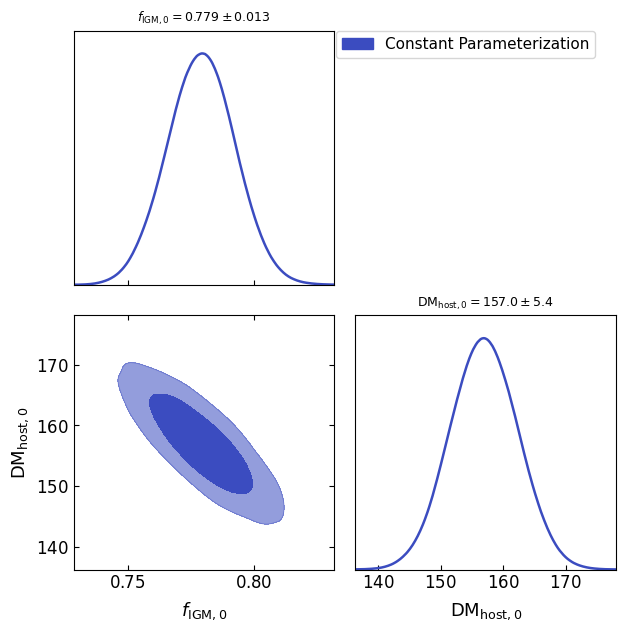

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/lcdm_caseA_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/lcdm_caseA_corner.png


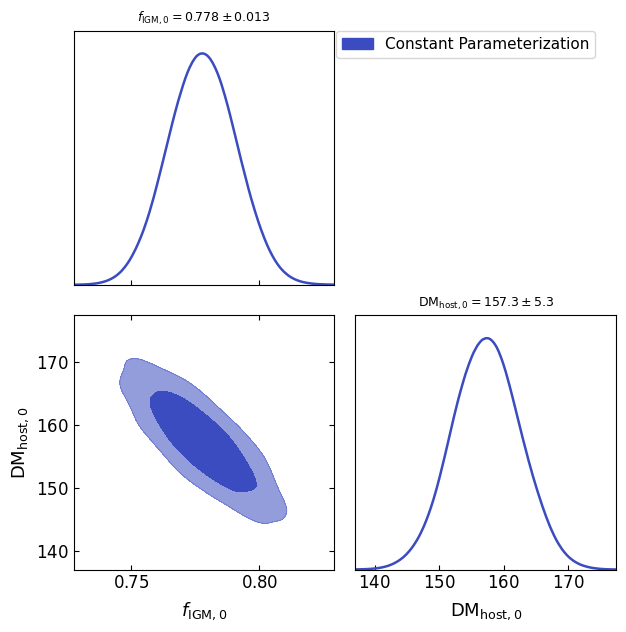

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/wcdm_caseA_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/wcdm_caseA_corner.png


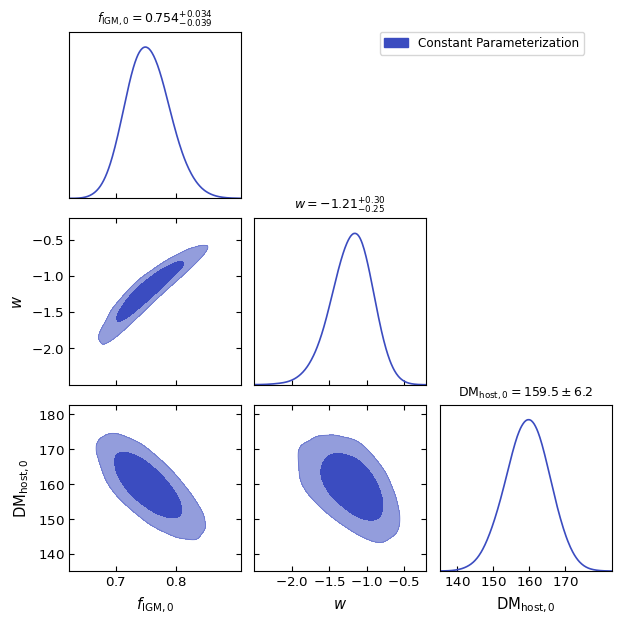

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/cpl_caseA_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/cpl_caseA_corner.png


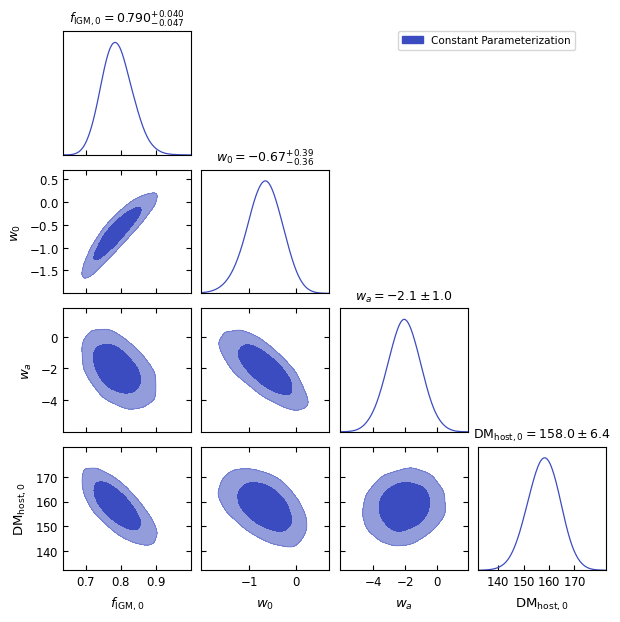

In [35]:
make_corner_plot(mi_A,   "Constant Parameterization",   "#3B4CC0", "mi_caseA_corner.pdf")
make_corner_plot(lcdm_A, "Constant Parameterization",   "#3B4CC0", "lcdm_caseA_corner.pdf")
make_corner_plot(wcdm_A, "Constant Parameterization",   "#3B4CC0", "wcdm_caseA_corner.pdf")
make_corner_plot(cpl_A,  "Constant Parameterization",   "#3B4CC0", "cpl_caseA_corner.pdf")

### 5.3 Case B — Time-dependent $f_{\rm IGM}$

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/mi_caseB_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/mi_caseB_corner.png


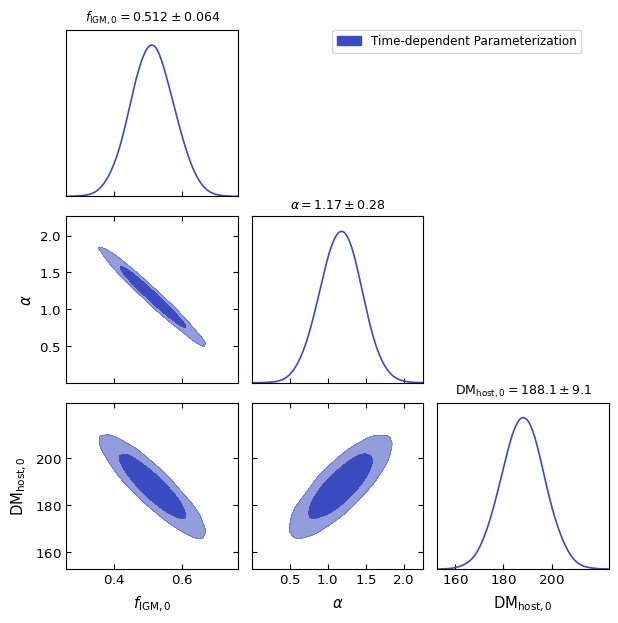

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/lcdm_caseB_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/lcdm_caseB_corner.png


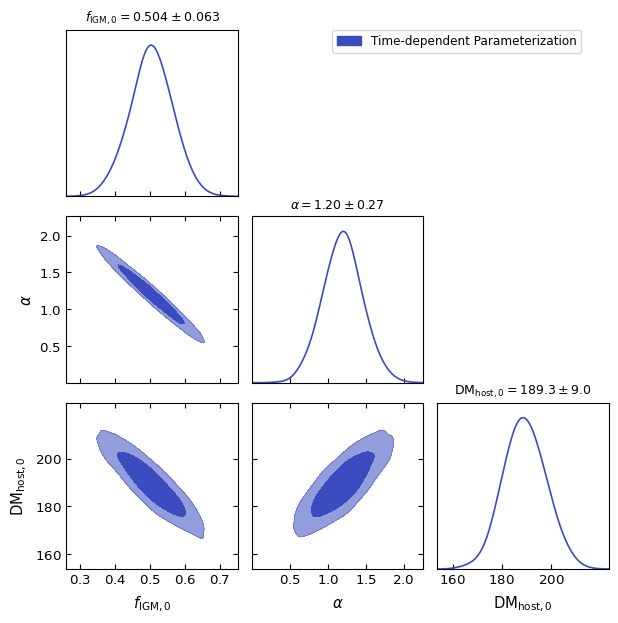

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/wcdm_caseB_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/wcdm_caseB_corner.png


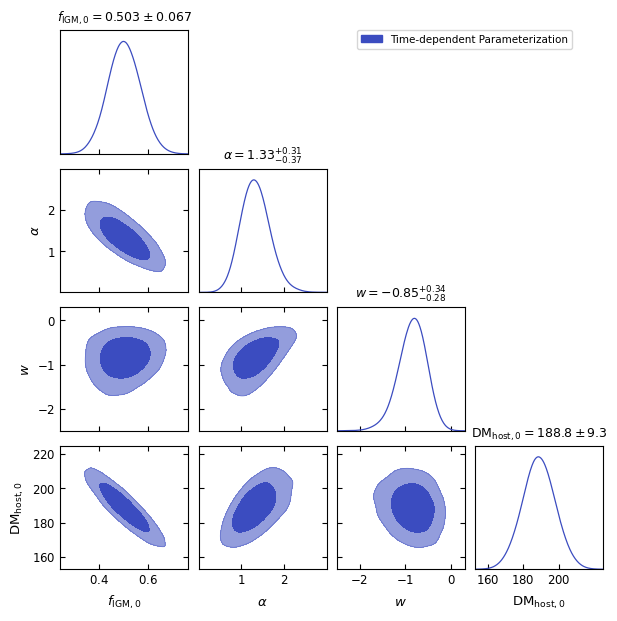

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/cpl_caseB_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/cpl_caseB_corner.png


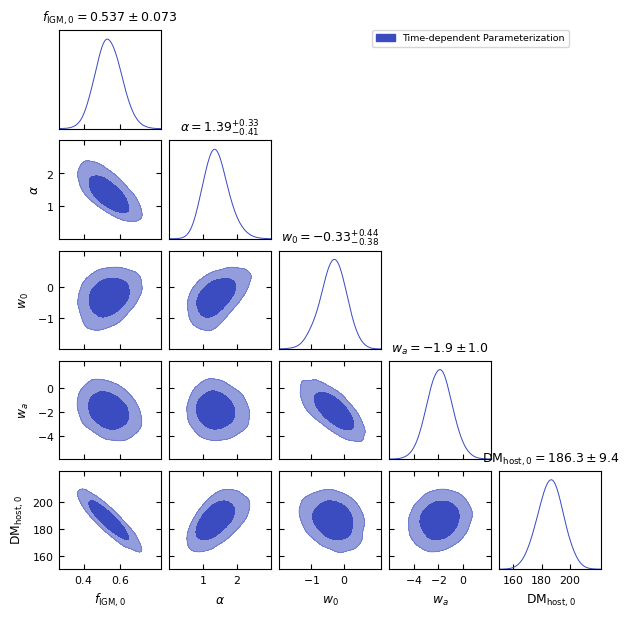

In [36]:
make_corner_plot(mi_B,   "Time-dependent Parameterization", "#3B4CC0", "mi_caseB_corner.pdf")
make_corner_plot(lcdm_B, "Time-dependent Parameterization", "#3B4CC0", "lcdm_caseB_corner.pdf")
make_corner_plot(wcdm_B, "Time-dependent Parameterization", "#3B4CC0", "wcdm_caseB_corner.pdf")
make_corner_plot(cpl_B,  "Time-dependent Parameterization", "#3B4CC0", "cpl_caseB_corner.pdf")

### 5.4 Case A vs Case B overlay — shared parameters per model

Each plot overlays the constant (blue) and time-dependent (red) posteriors on the parameters common to both cases: $f_{\rm IGM,0}$ and $\mathrm{DM}_{\rm host,0}$. For wCDM and CPL the dark energy parameter is also shown.

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/mi_overlay_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/mi_overlay_corner.png


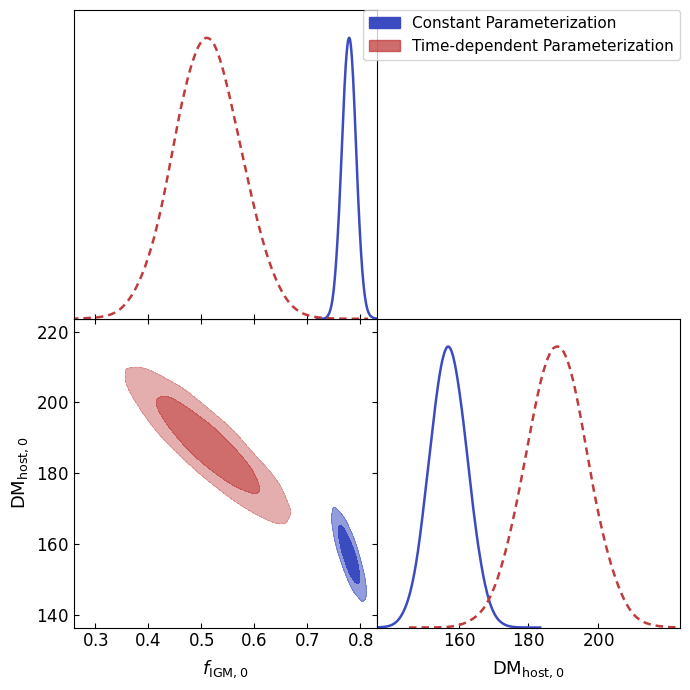

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/lcdm_overlay_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/lcdm_overlay_corner.png


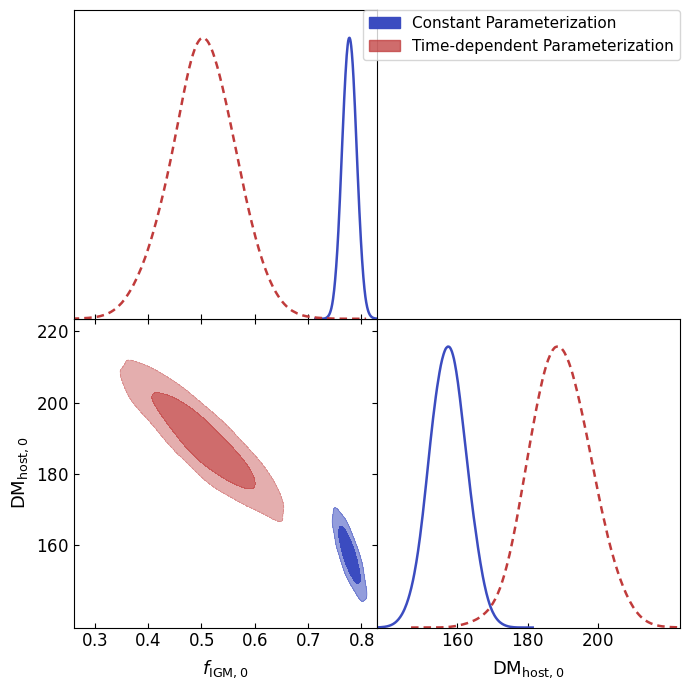

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/wcdm_overlay_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/wcdm_overlay_corner.png


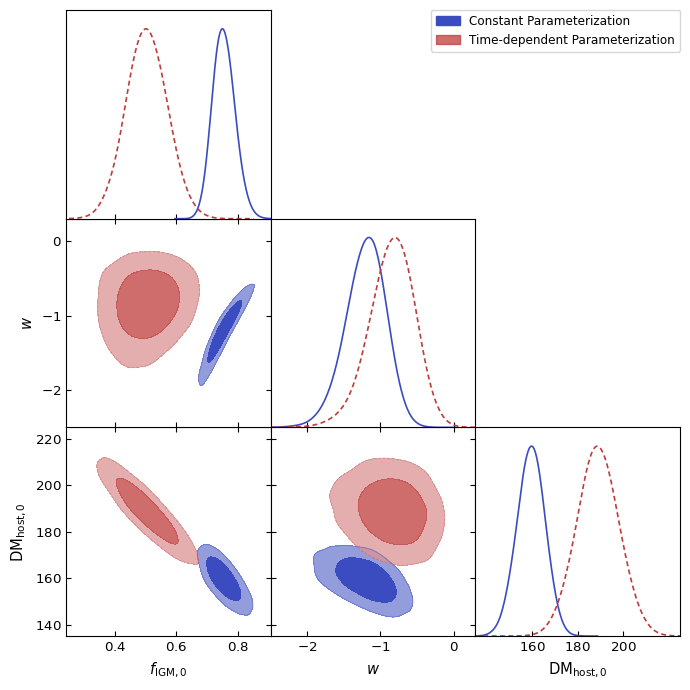

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/cpl_overlay_corner.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/cpl_overlay_corner.png


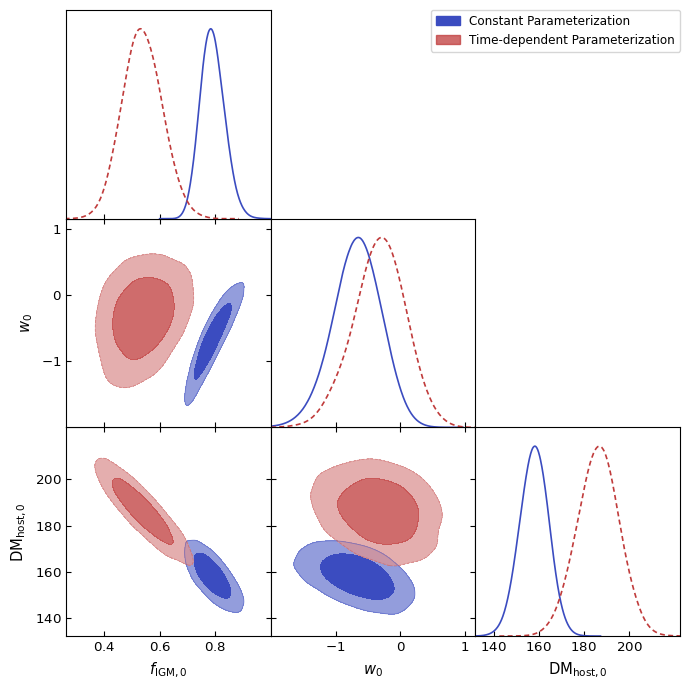

In [37]:
def make_overlay_plot(samp_A, samp_B, params, title_text, filename):
    g = gdplt.get_subplot_plotter(width_inch=7.0)

    g.settings.axes_fontsize            = 12
    g.settings.axes_labelsize          = 13
    g.settings.legend_fontsize         = 11
    g.settings.title_limit_fontsize    = 9
    g.settings.figure_legend_frame     = True
    g.settings.figure_legend_loc       = "upper right"
    g.settings.alpha_filled_add        = 0.75
    g.settings.solid_contour_palefactor = 0.45
    g.settings.linewidth               = 1.8
    g.settings.num_plot_contours       = 2
    g.settings.constrained_layout      = False

    g.triangle_plot(
        [samp_A, samp_B],
        params         = params,
        filled         = True,
        legend_labels  = ["Constant Parameterization",
                          "Time-dependent Parameterization"],
        contour_colors = ["#3B4CC0", "#C03B3B"],
        contour_ls     = ["-", "--"],
        legend_loc     = "upper right",
    )

    g.fig.subplots_adjust(top=0.88, hspace=0.12, wspace=0.08)

    n_params = len(params)
    title_y  = 1.15 if n_params <= 2 else 1.08
    for ax in g.fig.axes:
        if ax.title.get_text():
            ax.title.set_position([0.5, title_y])
            ax.title.set_fontsize(9)

    for ext in ["pdf", "png"]:
        fname = os.path.join(RESULTS_DIR, filename.replace(".pdf", f".{ext}"))
        g.fig.savefig(fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {fname}")
    plt.show()


make_overlay_plot(mi_A,   mi_B,   ["f_IGM_0", "DM_host_0"],
                  "Model-independent", "mi_overlay_corner.pdf")

make_overlay_plot(lcdm_A, lcdm_B, ["f_IGM_0", "DM_host_0"],
                  r"$\Lambda$CDM",    "lcdm_overlay_corner.pdf")

make_overlay_plot(wcdm_A, wcdm_B, ["f_IGM_0", "w", "DM_host_0"],
                  "wCDM",             "wcdm_overlay_corner.pdf")

make_overlay_plot(cpl_A,  cpl_B,  ["f_IGM_0", "w0", "DM_host_0"],
                  "CPL",             "cpl_overlay_corner.pdf")

## 6. Cosmological Parameter Constraints

Two-dimensional marginalized posteriors in the $w_0$–$w_a$ plane
at 1–2 $\sigma$ confidence levels, comparing cosmological models.
Since wCDM fixes $w_a = 0$, it appears as a 1D constraint on $w_0$
shown as a vertical band. The dashed lines mark the $\Lambda$CDM
point ($w_0 = -1,\, w_a = 0$).

Two plots are produced: one for Case A (constant $f_{\rm IGM}$)
and one for Case B (time-dependent $f_{\rm IGM}$).

Saved: w0wa_plane_caseA.pdf
Saved: w0wa_plane_caseA.png


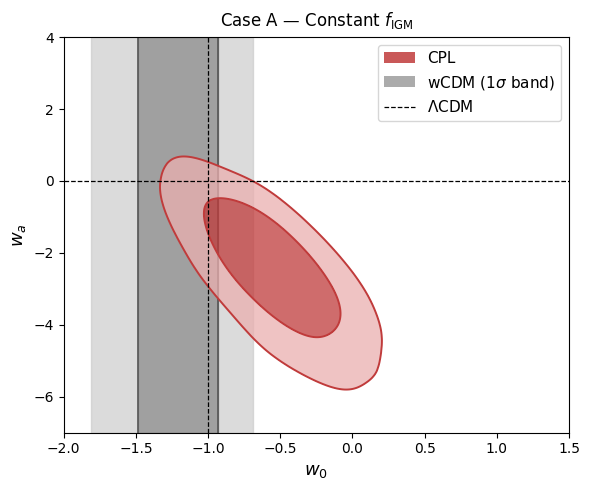

Saved: w0wa_plane_caseB.pdf
Saved: w0wa_plane_caseB.png


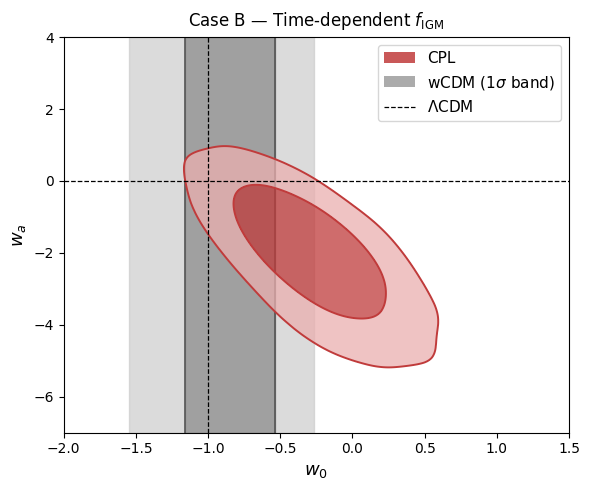

In [40]:
def plot_w0wa_plane(wcdm_samp, cpl_samp, case_label, filename):
    fig, ax = plt.subplots(figsize=(6, 5))

    # ── CPL: 2D filled contours at 1, 2 sigma ────────────────
    dens_cpl = cpl_samp.get2DDensityGridData(
        "w0", "wa",
        smooth_scale_2D=0.45
    )

    levels_sigma = [0.6827, 0.9545]  # 1, 2 sigma

    def get_contour_levels(dens, sigmas):
        d        = dens.P.flatten()
        d_sorted = np.sort(d)[::-1]
        cumsum   = np.cumsum(d_sorted)
        cumsum  /= cumsum[-1]
        levels   = []
        for s in sigmas:
            idx = np.searchsorted(cumsum, s)
            levels.append(d_sorted[idx])
        return sorted(levels)

    lvls_cpl        = get_contour_levels(dens_cpl, levels_sigma)
    cpl_colors_fill = ["#eaafaf", "#C03B3B"]  # light→dark (2σ→1σ)

    ax.contourf(dens_cpl.x, dens_cpl.y, dens_cpl.P.T,
                levels=lvls_cpl + [dens_cpl.P.max()],
                colors=cpl_colors_fill, alpha=0.75, zorder=2)
    ax.contour(dens_cpl.x, dens_cpl.y, dens_cpl.P.T,
               levels=lvls_cpl,
               colors="#C03B3B", linewidths=1.4, zorder=3)

    # ── wCDM: vertical band (wa = 0 fixed, w0 marginal) ──────
    dens_w = wcdm_samp.get1DDensity("w")
    w_vals = dens_w.x
    w_prob = dens_w.P

    def get_1d_bands(x, p, sigmas):
        cumulative  = np.cumsum(p)
        cumulative /= cumulative[-1]
        bands = []
        for s in sigmas:
            lo_idx = np.searchsorted(cumulative,  (1 - s) / 2)
            hi_idx = np.searchsorted(cumulative, 1 - (1 - s) / 2)
            bands.append((x[lo_idx], x[hi_idx]))
        return bands

    bands       = get_1d_bands(w_vals, w_prob, levels_sigma)
    band_colors = ["#cccccc", "#888888"]  # 2σ→1σ: light→dark

    for (wlo, whi), bc in zip(bands[::-1], band_colors):
        ax.axvspan(wlo, whi, color=bc, alpha=0.7, zorder=1)
    ax.axvline(bands[0][0], color="#555555", lw=1.2, zorder=1)
    ax.axvline(bands[0][1], color="#555555", lw=1.2, zorder=1)

    # ── ΛCDM reference lines ──────────────────────────────────
    ax.axvline(-1, color="k", ls="--", lw=0.9, zorder=5)
    ax.axhline( 0, color="k", ls="--", lw=0.9, zorder=5)

    # ── Legend ────────────────────────────────────────────────
    from matplotlib.patches import Patch
    from matplotlib.lines   import Line2D

    legend_elements = [
        Patch(facecolor="#C03B3B", alpha=0.85, label="CPL"),
        Patch(facecolor="#888888", alpha=0.70, label=r"wCDM ($1\sigma$ band)"),
        Line2D([0], [0], color="k", ls="--", lw=0.9, label=r"$\Lambda$CDM"),
    ]
    ax.legend(handles=legend_elements, loc="upper right",
              fontsize=11, frameon=True)

    ax.set_xlabel(r"$w_0$", fontsize=13)
    ax.set_ylabel(r"$w_a$", fontsize=13)
    ax.set_xlim(-2.0, 1.5)
    ax.set_ylim(-7,   4)
    ax.set_title(case_label, fontsize=12, pad=8)

    plt.tight_layout()
    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(RESULTS_DIR, f"{filename}.{ext}"),
                    bbox_inches="tight", dpi=300)
        print(f"Saved: {filename}.{ext}")
    plt.show()

plot_w0wa_plane(wcdm_A, cpl_A,
                r"Case A — Constant $f_{\rm IGM}$",
                "w0wa_plane_caseA")

plot_w0wa_plane(wcdm_B, cpl_B,
                r"Case B — Time-dependent $f_{\rm IGM}$",
                "w0wa_plane_caseB")

## 7. Cross-model Overlay Corner Plots

We overlay the posteriors of the three cosmological models
(ΛCDM, wCDM, CPL) on the parameters common to all:
$f_{\rm IGM,0}$ and $\mathrm{DM}_{\rm host,0}$, for both
Case A and Case B separately. This allows a direct visual
comparison of how the choice of cosmological model affects
the inferred baryon fraction.

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/crossmodel_caseA.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/crossmodel_caseA.png


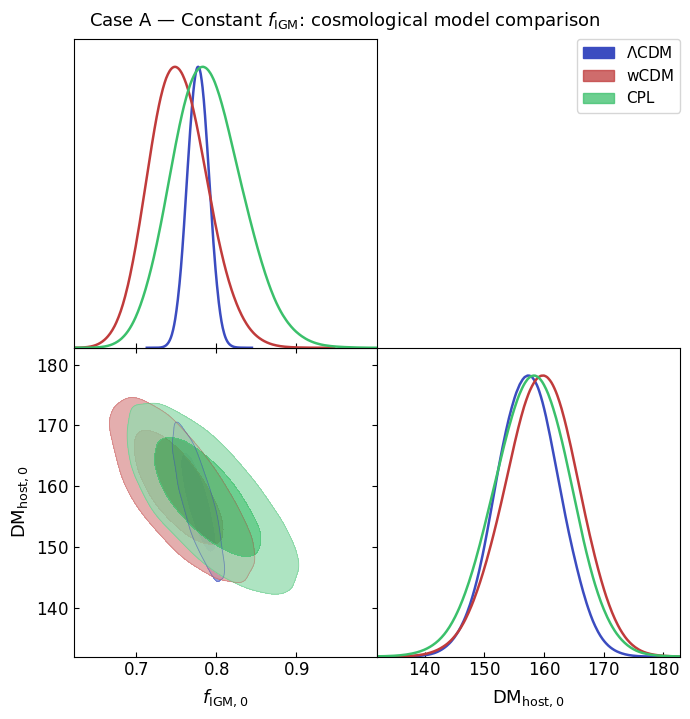

Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/crossmodel_caseB.pdf
Saved: /content/drive/MyDrive/frb_cosmology_thesis/results/crossmodel_caseB.png


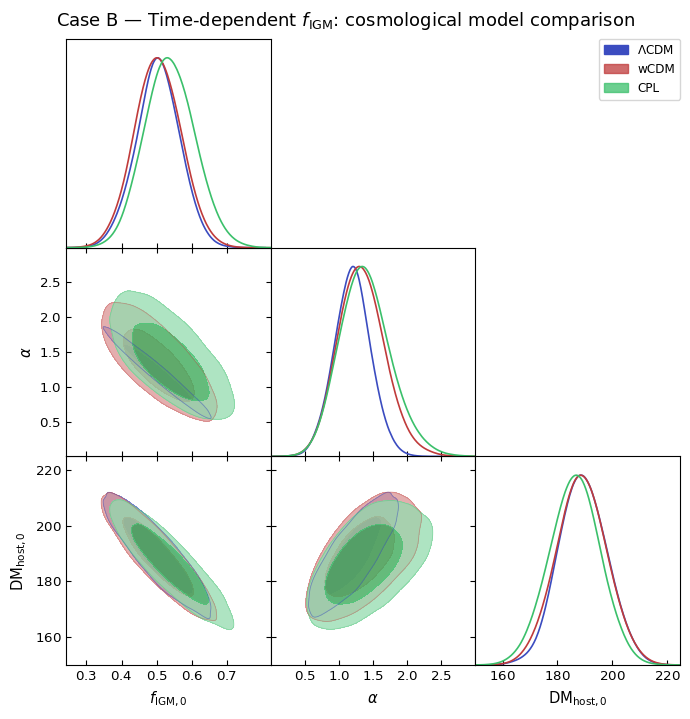

In [41]:
def make_crossmodel_overlay(samples_list, labels_list, colors_list,
                             params, suptitle, filename):
    g = gdplt.get_subplot_plotter(width_inch=7.0)
    g.settings.axes_fontsize             = 12
    g.settings.axes_labelsize            = 13
    g.settings.legend_fontsize           = 11
    g.settings.title_limit_fontsize      = 9
    g.settings.figure_legend_frame       = True
    g.settings.alpha_filled_add          = 0.75
    g.settings.solid_contour_palefactor  = 0.45
    g.settings.linewidth                 = 1.8
    g.settings.num_plot_contours         = 2
    g.settings.constrained_layout        = False

    g.triangle_plot(
        samples_list,
        params         = params,
        filled         = True,
        legend_labels  = labels_list,
        contour_colors = colors_list,
        legend_loc     = "upper right",
    )
    g.fig.subplots_adjust(top=0.88, hspace=0.12, wspace=0.08)
    g.fig.suptitle(suptitle, y=1.02, fontsize=13)

    for ext in ["pdf", "png"]:
        fname = os.path.join(RESULTS_DIR,
                             filename.replace(".pdf", f".{ext}"))
        g.fig.savefig(fname, bbox_inches="tight", dpi=300)
        print(f"Saved: {fname}")
    plt.show()

# Case A: ΛCDM vs wCDM vs CPL
make_crossmodel_overlay(
    [lcdm_A, wcdm_A, cpl_A],
    [r"$\Lambda$CDM", "wCDM", "CPL"],
    ["#3B4CC0", "#C03B3B", "#3BC06B"],
    ["f_IGM_0", "DM_host_0"],
    r"Case A — Constant $f_{\rm IGM}$: cosmological model comparison",
    "crossmodel_caseA.pdf"
)

# Case B: ΛCDM vs wCDM vs CPL
make_crossmodel_overlay(
    [lcdm_B, wcdm_B, cpl_B],
    [r"$\Lambda$CDM", "wCDM", "CPL"],
    ["#3B4CC0", "#C03B3B", "#3BC06B"],
    ["f_IGM_0", "alpha", "DM_host_0"],
    r"Case B — Time-dependent $f_{\rm IGM}$: cosmological model comparison",
    "crossmodel_caseB.pdf"
)

## 8. Parameter Constraints Tables

### 8.1 Full parameter table

Median and 68% credible intervals for all free parameters,
for both Case A (constant $f_{\rm IGM}$) and Case B
(time-dependent $f_{\rm IGM}$). A dash (—) indicates the
parameter is not part of that model.

In [42]:
def get_stats(chain, idx):
    p16, p50, p84 = np.percentile(chain[:, idx], [16, 50, 84])
    return p50, p84 - p50, p50 - p16

def fmt(val, hi, lo):
    return f"{val:.3f} +{hi:.3f} -{lo:.3f}"

sep = "─" * 100

# ── Case A ────────────────────────────────────────────────────
# lcdm_A : [f_IGM_0, DM_host_0]
# wcdm_A : [f_IGM_0, w, DM_host_0]
# cpl_A  : [f_IGM_0, w0, wa, DM_host_0]

print(sep)
print("TABLE — Parameter Constraints, Case A (Constant f_IGM)")
print(sep)
print(f"{'Model':<10} {'f_IGM,0':>22} {'w / w0':>22} "
      f"{'wa':>22} {'DM_host,0':>22}")
print(sep)

f, fh, fl = get_stats(lcdm_A_chain, 0)
D, Dh, Dl = get_stats(lcdm_A_chain, 1)
print(f"{'ΛCDM':<10} {fmt(f,fh,fl):>22} {'—':>22} "
      f"{'—':>22} {fmt(D,Dh,Dl):>22}")

f, fh, fl = get_stats(wcdm_A_chain, 0)
w, wh, wl = get_stats(wcdm_A_chain, 1)
D, Dh, Dl = get_stats(wcdm_A_chain, 2)
print(f"{'wCDM':<10} {fmt(f,fh,fl):>22} {fmt(w,wh,wl):>22} "
      f"{'—':>22} {fmt(D,Dh,Dl):>22}")

f,  fh,  fl  = get_stats(cpl_A_chain, 0)
w0, w0h, w0l = get_stats(cpl_A_chain, 1)
wa, wah, wal = get_stats(cpl_A_chain, 2)
D,  Dh,  Dl  = get_stats(cpl_A_chain, 3)
print(f"{'CPL':<10} {fmt(f,fh,fl):>22} {fmt(w0,w0h,w0l):>22} "
      f"{fmt(wa,wah,wal):>22} {fmt(D,Dh,Dl):>22}")
print(sep)

# ── Case B ────────────────────────────────────────────────────
# lcdm_B : [f_IGM_0, alpha, DM_host_0]
# wcdm_B : [f_IGM_0, alpha, w, DM_host_0]
# cpl_B  : [f_IGM_0, alpha, w0, wa, DM_host_0]

print()
print(sep)
print("TABLE — Parameter Constraints, Case B (Time-dependent f_IGM)")
print(sep)
print(f"{'Model':<10} {'f_IGM,0':>22} {'alpha':>22} {'w / w0':>22} "
      f"{'wa':>22} {'DM_host,0':>22}")
print(sep)

f, fh, fl = get_stats(lcdm_B_chain, 0)
a, ah, al = get_stats(lcdm_B_chain, 1)
D, Dh, Dl = get_stats(lcdm_B_chain, 2)
print(f"{'ΛCDM':<10} {fmt(f,fh,fl):>22} {fmt(a,ah,al):>22} "
      f"{'—':>22} {'—':>22} {fmt(D,Dh,Dl):>22}")

f, fh, fl = get_stats(wcdm_B_chain, 0)
a, ah, al = get_stats(wcdm_B_chain, 1)
w, wh, wl = get_stats(wcdm_B_chain, 2)
D, Dh, Dl = get_stats(wcdm_B_chain, 3)
print(f"{'wCDM':<10} {fmt(f,fh,fl):>22} {fmt(a,ah,al):>22} "
      f"{fmt(w,wh,wl):>22} {'—':>22} {fmt(D,Dh,Dl):>22}")

f,  fh,  fl  = get_stats(cpl_B_chain, 0)
a,  ah,  al  = get_stats(cpl_B_chain, 1)
w0, w0h, w0l = get_stats(cpl_B_chain, 2)
wa, wah, wal = get_stats(cpl_B_chain, 3)
D,  Dh,  Dl  = get_stats(cpl_B_chain, 4)
print(f"{'CPL':<10} {fmt(f,fh,fl):>22} {fmt(a,ah,al):>22} "
      f"{fmt(w0,w0h,w0l):>22} {fmt(wa,wah,wal):>22} {fmt(D,Dh,Dl):>22}")
print(sep)

────────────────────────────────────────────────────────────────────────────────────────────────────
TABLE — Parameter Constraints, Case A (Constant f_IGM)
────────────────────────────────────────────────────────────────────────────────────────────────────
Model                     f_IGM,0                 w / w0                     wa              DM_host,0
────────────────────────────────────────────────────────────────────────────────────────────────────
ΛCDM          0.778 +0.013 -0.013                      —                      —  157.302 +5.309 -5.245
wCDM          0.752 +0.038 -0.035   -1.192 +0.260 -0.290                      —  159.594 +6.061 -6.306
CPL           0.788 +0.046 -0.042   -0.662 +0.368 -0.379   -2.061 +1.035 -1.037  158.071 +6.287 -6.535
────────────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────────────────────────
TABLE — Parameter Constrain

### 8.2 Cosmological parameters only

Constraints on $w$ (wCDM) and $w_0$, $w_a$ (CPL) for both cases.
$\Lambda$CDM has no free cosmological parameters ($w = -1$ fixed).

In [44]:
sep = "─" * 75
print(sep)
print("TABLE — Cosmological Parameter Constraints")
print(sep)
print(f"{'Model':<10} {'Case':<8} {'w / w0':>22} {'wa':>22}")
print(sep)

w, wh, wl = get_stats(wcdm_A_chain, 1)
print(f"{'wCDM':<10} {'A':<8} {fmt(w,wh,wl):>22} {'—':>22}")

w, wh, wl = get_stats(wcdm_B_chain, 2)
print(f"{'wCDM':<10} {'B':<8} {fmt(w,wh,wl):>22} {'—':>22}")

print(sep)

w0, w0h, w0l = get_stats(cpl_A_chain, 1)
wa, wah, wal = get_stats(cpl_A_chain, 2)
print(f"{'CPL':<10} {'A':<8} {fmt(w0,w0h,w0l):>22} {fmt(wa,wah,wal):>22}")

w0, w0h, w0l = get_stats(cpl_B_chain, 2)
wa, wah, wal = get_stats(cpl_B_chain, 3)
print(f"{'CPL':<10} {'B':<8} {fmt(w0,w0h,w0l):>22} {fmt(wa,wah,wal):>22}")

print(sep)
print("Note: ΛCDM has no free cosmological parameters (w = -1 fixed).")

───────────────────────────────────────────────────────────────────────────
TABLE — Cosmological Parameter Constraints
───────────────────────────────────────────────────────────────────────────
Model      Case                     w / w0                     wa
───────────────────────────────────────────────────────────────────────────
wCDM       A          -1.192 +0.260 -0.290                      —
wCDM       B          -0.831 +0.292 -0.323                      —
───────────────────────────────────────────────────────────────────────────
CPL        A          -0.662 +0.368 -0.379   -2.061 +1.035 -1.037
CPL        B          -0.312 +0.394 -0.422   -1.899 +1.032 -1.031
───────────────────────────────────────────────────────────────────────────
Note: ΛCDM has no free cosmological parameters (w = -1 fixed).


## 9. Bayesian Evidence and Model Comparison

We perform model comparison using the Bayes Factor (BF):
$$
\mathcal{B}_{01} = \frac{\mathcal{Z}_0}{\mathcal{Z}_1}
= e^{\ln\mathcal{Z}_0 - \ln\mathcal{Z}_1}
$$
$\mathcal{B}_{01} > 1$ favours $M_0$; $\mathcal{B}_{01} < 1$
favours $M_1$. We use $\log_{10}(\mathcal{B}_{01})$ and the
Jeffreys scale:

| $\mathcal{B}_{01}$ | $\log_{10}(\mathcal{B}_{01})$ | Strength of evidence |
|:---:|:---:|:---|
| $1$–$3.2$ | $0$ to $0.5$ | Barely worth mentioning |
| $3.2$–$10$ | $0.5$ to $1.0$ | Substantial |
| $10$–$32$ | $1.0$ to $1.5$ | Strong |
| $32$–$100$ | $1.5$ to $2.0$ | Very strong |
| $> 100$ | $> 2.0$ | Decisive |

For $\mathcal{B}_{01} < 1$ the same scale applies to
$1/\mathcal{B}_{01}$, giving evidence for $M_1$.

### 9.1 Constant vs Time-dependent $f_{\rm IGM}$ within each model

$M_0$ = Case A (constant), $M_1$ = Case B (time-dependent).
$\log_{10}\mathcal{B}_{AB} < 0$ favours Case B.

In [45]:
with open(os.path.join(EVIDENCE_DIR, "bayes_evidence.json")) as jf:
    ev = json.load(jf)

all_models = {
    "model_independent": "Model-independent",
    "lcdm":              "ΛCDM",
    "wcdm":              "wCDM",
    "cpl":               "CPL",
}
cosmo_models = {
    "lcdm": "ΛCDM",
    "wcdm": "wCDM",
    "cpl":  "CPL",
}

def jeffreys_bf(log10_bf):
    a = abs(log10_bf)
    if a < 0.5:   strength = "Barely worth mentioning"
    elif a < 1.0: strength = "Substantial"
    elif a < 1.5: strength = "Strong"
    elif a < 2.0: strength = "Very strong"
    else:         strength = "Decisive"
    winner = "favours A" if log10_bf > 0 else "favours B"
    return strength, winner

sep = "=" * 92
print(sep)
print("TABLE 1 — Bayes Factor: Constant (A) vs Time-dependent (B) f_IGM")
print("  M0 = Case A, M1 = Case B  →  log10(BF) < 0 favours Case B")
print(sep)
print(f"{'Model':<22} {'ln Z_A':>10} {'ln Z_B':>10} "
      f"{'BF_AB':>12} {'log10(BF)':>11}  Verdict")
print("-" * 92)

for key, label in all_models.items():
    lzA      = ev[key]["case_A"]["logz"]
    lzB      = ev[key]["case_B"]["logz"]
    ln_bf    = lzA - lzB
    bf       = np.exp(ln_bf)
    log10_bf = np.log10(bf)
    strength, winner = jeffreys_bf(log10_bf)
    print(f"{label:<22} {lzA:>10.2f} {lzB:>10.2f} "
          f"{bf:>12.4f} {log10_bf:>11.3f}  {strength} — {winner}")

TABLE 1 — Bayes Factor: Constant (A) vs Time-dependent (B) f_IGM
  M0 = Case A, M1 = Case B  →  log10(BF) < 0 favours Case B
Model                      ln Z_A     ln Z_B        BF_AB   log10(BF)  Verdict
--------------------------------------------------------------------------------------------
Model-independent         -560.50    -553.64       0.0010      -2.983  Decisive — favours B
ΛCDM                      -560.91    -552.52       0.0002      -3.643  Decisive — favours B
wCDM                      -562.34    -553.76       0.0002      -3.726  Decisive — favours B
CPL                       -560.42    -552.36       0.0003      -3.499  Decisive — favours B


### 9.2 Pairwise cross-model comparison

We compare the three cosmological models pairwise using the
Bayes Factor, for both Case A and Case B separately.
$\log_{10}\mathcal{B}_{01} > 0$ (✓) favours the row model
over the column model.

In [46]:
def pairwise_bf_table(case_key, title):
    keys   = list(cosmo_models.keys())
    labels = list(cosmo_models.values())

    print("=" * 82)
    print(f"TABLE — Pairwise Bayes Factors, {title}")
    print("  log10(BF_row,col): + favours row, − favours column")
    print("=" * 82)

    col_w = 24
    print(f"{'':12}", end="")
    for lab in labels:
        print(f"{lab:>{col_w}}", end="")
    print()
    print("-" * 82)

    for ki, li in zip(keys, labels):
        lzi = ev[ki][case_key]["logz"]
        ezi = ev[ki][case_key]["logzerr"]
        print(f"{li:<12}", end="")
        for kj, lj in zip(keys, labels):
            if ki == kj:
                print(f"{'—':>{col_w}}", end="")
            else:
                lzj      = ev[kj][case_key]["logz"]
                ln_bf    = lzi - lzj
                log10_bf = ln_bf / np.log(10)
                strength, _ = jeffreys_bf(log10_bf)
                short = {"Barely worth mentioning": "Barely",
                         "Substantial":             "Subs.",
                         "Strong":                  "Strong",
                         "Very strong":             "V.Strong",
                         "Decisive":                "Decisive"}[strength]
                winner = "✓" if log10_bf > 0 else "✗"
                cell   = f"{winner} {log10_bf:+.3f} ({short})"
                print(f"{cell:>{col_w}}", end="")
        print()

    print()
    print("  ✓ row preferred | ✗ column preferred")
    print("  Scale: <0.5 Barely | 0.5-1 Subs. | 1-1.5 Strong |"
          " 1.5-2 V.Strong | >2 Decisive")
    print()

pairwise_bf_table("case_A", "Constant f_IGM (Case A)")
pairwise_bf_table("case_B", "Time-dependent f_IGM (Case B)")

TABLE — Pairwise Bayes Factors, Constant f_IGM (Case A)
  log10(BF_row,col): + favours row, − favours column
                                ΛCDM                    wCDM                     CPL
----------------------------------------------------------------------------------
ΛCDM                               —        ✓ +0.623 (Subs.)       ✗ -0.214 (Barely)
wCDM                ✗ -0.623 (Subs.)                       —        ✗ -0.837 (Subs.)
CPL                ✓ +0.214 (Barely)        ✓ +0.837 (Subs.)                       —

  ✓ row preferred | ✗ column preferred
  Scale: <0.5 Barely | 0.5-1 Subs. | 1-1.5 Strong | 1.5-2 V.Strong | >2 Decisive

TABLE — Pairwise Bayes Factors, Time-dependent f_IGM (Case B)
  log10(BF_row,col): + favours row, − favours column
                                ΛCDM                    wCDM                     CPL
----------------------------------------------------------------------------------
ΛCDM                               —        ✓ +0.539 (Subs.)   

### 9.3 Summary

- **Table 1** shows that all cosmological frameworks decisively
  favour the time-dependent $f_{\rm IGM}$ parameterisation
  (Case B) over the constant one (Case A), with
  $\log_{10}\mathcal{B}_{AB} \ll 0$ in every case — confirming
  that evolution of the baryon fraction in the IGM is required
  by the data.

- **Pairwise comparisons** (Section 9.2) show that wCDM is
  consistently disfavoured relative to both $\Lambda$CDM and
  CPL (substantially to strongly), while the evidence between
  $\Lambda$CDM and CPL is barely worth mentioning in both cases.

- The FRB data therefore cannot distinguish between a
  cosmological constant ($\Lambda$CDM) and a dynamical dark
  energy with two parameters (CPL), but consistently disfavour
  a single constant equation-of-state parameter $w$ (wCDM).